## Random features can make non-linear classes separable (toy demo)

This notebook lets you choose a dataset that is **not linearly separable** in its original space (e.g. XOR / circles), then applies a **random feature map** (random projection + optional nonlinearity) and measures how well a **linear** classifier can separate the classes.

Edit the `cfg = Config(...)` cell to play around with:
- dataset type (`"xor"`, `"circles"`, or `"ohe"`)
- projection dimensionality
- additive noise
- samples per class
- nonlinearity


In [28]:
from __future__ import annotations

from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.datasets import make_circles
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


In [29]:
@dataclass
class Config:
    """Configuration for the random feature demo.

    Attributes:
        dataset: Which dataset to generate. Options:
            - "xor": 2D XOR (not linearly separable)
            - "circles": concentric circles (not linearly separable)
            - "ohe": one-hot classes (linearly separable; mainly for comparison)
        n_classes: Used only for dataset="ohe".
        n_per_class: Samples per class (or per label for XOR/circles).
        proj_dim: Output dimensionality after random feature map.
        noise_std: Gaussian noise added after the linear projection.
        use_nonlinearity: If True, apply tanh after projection.
        normalise_before_classify: If True, standardise features for classification.
        seed: RNG seed.
    """

    dataset: str = "circles"
    n_classes: int = 6
    n_per_class: int = 300
    proj_dim: int = 64
    noise_std: float = 0.30
    use_nonlinearity: bool = True
    normalise_before_classify: bool = True
    seed: int = 0


cfg = Config(
    dataset="circles",
    n_classes=6,
    n_per_class=300,
    proj_dim=512,
    noise_std=0.30,
    use_nonlinearity=True,
    normalise_before_classify=True,
    seed=0,
)

cfg


Config(dataset='circles', n_classes=6, n_per_class=300, proj_dim=512, noise_std=0.3, use_nonlinearity=True, normalise_before_classify=True, seed=0)

In [30]:
def make_ohe_dataset(n_classes: int, n_per_class: int, seed: int) -> tuple[np.ndarray, np.ndarray]:
    """Create an OHE dataset.

    Args:
        n_classes: Number of classes.
        n_per_class: Samples per class.
        seed: Random seed.

    Returns:
        (X, y) where X is (N, n_classes) one-hot and y is (N,) labels.
    """
    rng = np.random.default_rng(seed)
    y = np.repeat(np.arange(n_classes), n_per_class)
    rng.shuffle(y)
    X = np.eye(n_classes, dtype=float)[y]
    return X, y


def make_xor_dataset(n_per_class: int, seed: int, noise_std: float = 0.20) -> tuple[np.ndarray, np.ndarray]:
    """Create a 2D XOR dataset (not linearly separable).

    Args:
        n_per_class: Samples per label.
        seed: Random seed.
        noise_std: Gaussian noise on the 2D coordinates.

    Returns:
        (X, y) where X is (N, 2) and y is (N,) in {0,1}.
    """
    rng = np.random.default_rng(seed)
    # Four corners of the square
    corners = np.array([
        [-1.0, -1.0],
        [-1.0,  1.0],
        [ 1.0, -1.0],
        [ 1.0,  1.0],
    ])
    labels = np.array([0, 1, 1, 0])  # XOR
    idx = rng.integers(0, 4, size=2 * n_per_class)
    X = corners[idx] + rng.normal(0.0, noise_std, size=(2 * n_per_class, 2))
    y = labels[idx]
    return X, y


def make_circles_dataset(n_per_class: int, seed: int, noise: float = 0.12, factor: float = 0.45) -> tuple[np.ndarray, np.ndarray]:
    """Create concentric circles (not linearly separable).

    Args:
        n_per_class: Samples per label.
        seed: Random seed.
        noise: Noise passed to sklearn's make_circles.
        factor: Inner circle scale.

    Returns:
        (X, y) where X is (N, 2) and y is (N,) in {0,1}.
    """
    X, y = make_circles(n_samples=2 * n_per_class, noise=noise, factor=factor, random_state=seed)
    return X.astype(float), y.astype(int)


def make_dataset(cfg: Config) -> tuple[np.ndarray, np.ndarray, str]:
    """Generate the chosen dataset.

    Returns:
        (X, y, name).
    """
    ds = cfg.dataset.lower().strip()
    if ds == "ohe":
        X, y = make_ohe_dataset(cfg.n_classes, cfg.n_per_class, cfg.seed)
        return X, y, "OHE classes"
    if ds == "xor":
        X, y = make_xor_dataset(cfg.n_per_class, cfg.seed, noise_std=0.25)
        return X, y, "XOR (2D)"
    if ds == "circles":
        X, y = make_circles_dataset(cfg.n_per_class, cfg.seed, noise=0.12, factor=0.45)
        return X, y, "Circles (2D)"
    raise ValueError(f"Unknown dataset: {cfg.dataset!r}")


def random_project(
    X: np.ndarray,
    proj_dim: int,
    noise_std: float,
    seed: int,
    use_nonlinearity: bool,
) -> tuple[np.ndarray, np.ndarray]:
    """Project inputs with a random matrix and (optionally) apply a nonlinearity.

    Args:
        X: (N, D_in) input matrix.
        proj_dim: Output dimension.
        noise_std: Gaussian noise applied after projection.
        seed: Random seed.
        use_nonlinearity: Whether to apply tanh.

    Returns:
        (Z, W) where Z is (N, proj_dim) and W is (D_in, proj_dim).
    """
    rng = np.random.default_rng(seed)
    d_in = X.shape[1]
    W = rng.normal(0.0, 1.0 / np.sqrt(d_in), size=(d_in, proj_dim))
    Z = X @ W
    if noise_std > 0:
        Z = Z + rng.normal(0.0, noise_std, size=Z.shape)
    if use_nonlinearity:
        Z = np.tanh(Z)
    return Z, W


def cv_linear_separability(Z: np.ndarray, y: np.ndarray, normalise: bool, seed: int) -> np.ndarray:
    """Compute 5-fold CV accuracy of a linear SVM."""
    cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    svm = LinearSVC(dual="auto", random_state=seed)
    if normalise:
        model = Pipeline([("sc", StandardScaler()), ("svm", svm)])
    else:
        model = Pipeline([("svm", svm)])
    return cross_val_score(model, Z, y, cv=cv5, scoring="accuracy")


In [31]:
X, y, ds_name = make_dataset(cfg)
Z, W = random_project(
    X,
    proj_dim=cfg.proj_dim,
    noise_std=cfg.noise_std,
    seed=cfg.seed,
    use_nonlinearity=cfg.use_nonlinearity,
)

acc_in = cv_linear_separability(X, y, normalise=cfg.normalise_before_classify, seed=cfg.seed)
acc_proj = cv_linear_separability(Z, y, normalise=cfg.normalise_before_classify, seed=cfg.seed)

print(f"Dataset: {ds_name}")
print(f"Input dim = {X.shape[1]} → CV acc: {acc_in.mean():.3f} ± {acc_in.std():.3f}")
print(
    f"Random features dim = {Z.shape[1]} (noise={cfg.noise_std}, tanh={cfg.use_nonlinearity}) "
    f"→ CV acc: {acc_proj.mean():.3f} ± {acc_proj.std():.3f}"
)


Dataset: Circles (2D)
Input dim = 2 → CV acc: 0.468 ± 0.021
Random features dim = 512 (noise=0.3, tanh=True) → CV acc: 0.515 ± 0.023


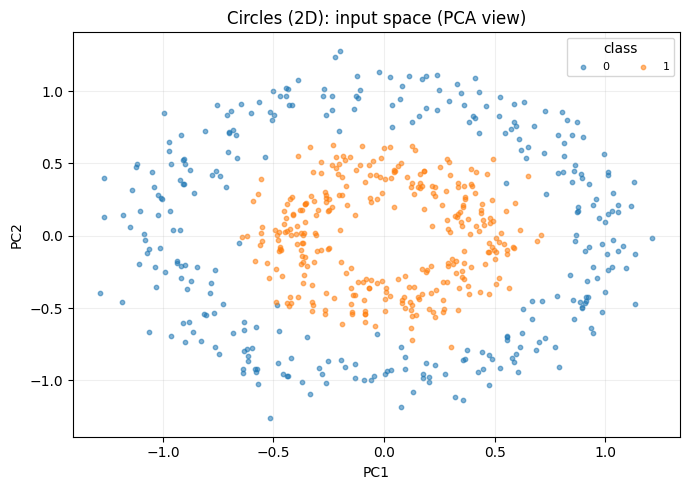

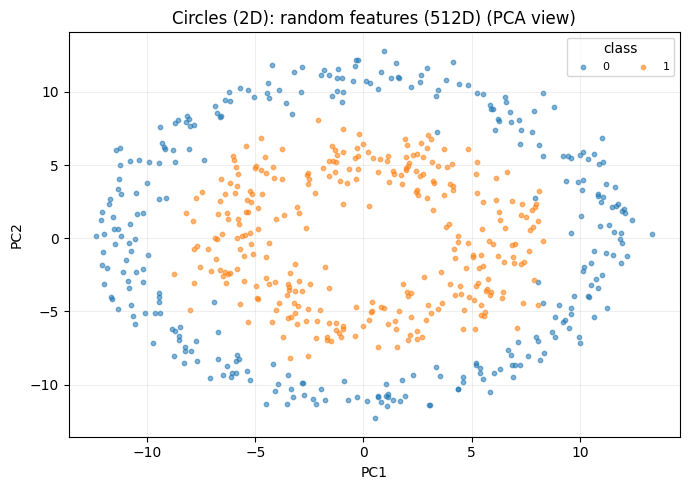

In [32]:
def plot_pca_scatter(features: np.ndarray, y: np.ndarray, title: str, seed: int) -> None:
    """Plot a 2D PCA scatter coloured by class."""
    pca = PCA(n_components=2, random_state=seed)
    X2 = pca.fit_transform(features)

    fig, ax = plt.subplots(1, 1, figsize=(7, 5))
    for c in np.unique(y):
        m = y == c
        ax.scatter(X2[m, 0], X2[m, 1], s=10, alpha=0.55, label=str(c))
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(title="class", ncol=3, fontsize=8)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


plot_pca_scatter(X, y, f"{ds_name}: input space (PCA view)", seed=cfg.seed)
plot_pca_scatter(Z, y, f"{ds_name}: random features ({cfg.proj_dim}D) (PCA view)", seed=cfg.seed)


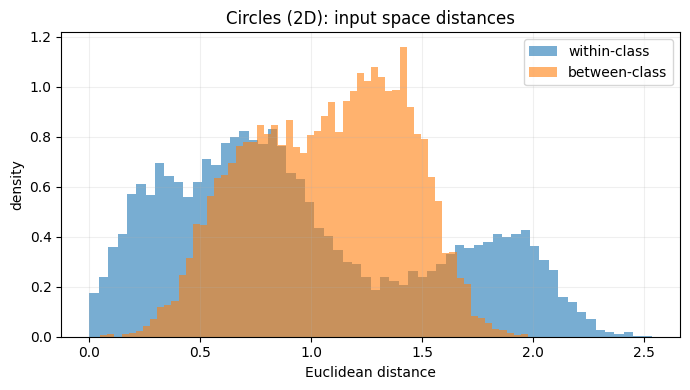

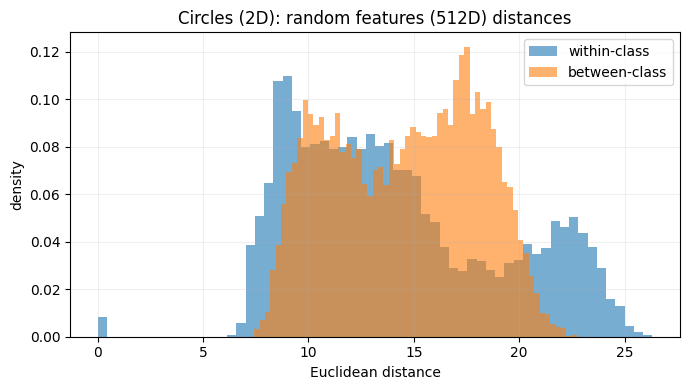

Linear SVM on random features — 5-fold CV acc: 0.515 ± 0.023


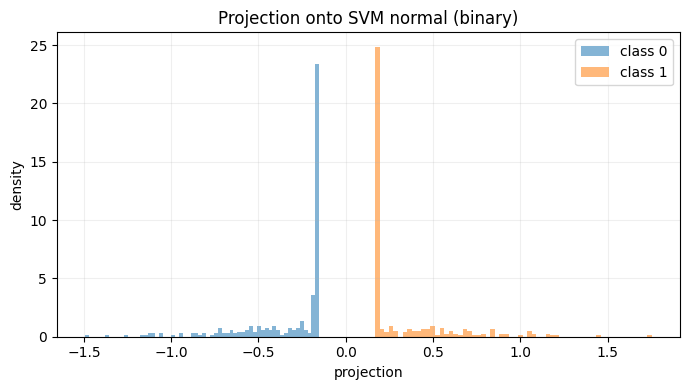

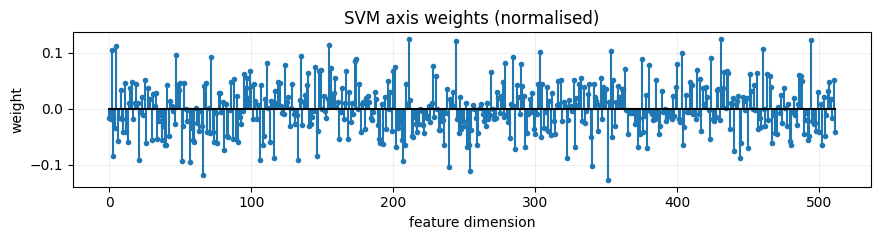

In [33]:
def plot_pairwise_distances(features: np.ndarray, y: np.ndarray, title: str) -> None:
    """Plot within-class vs between-class distance distributions."""
    rng = np.random.default_rng(0)
    n = len(y)
    idx1 = rng.integers(0, n, size=20_000)
    idx2 = rng.integers(0, n, size=20_000)
    d = np.linalg.norm(features[idx1] - features[idx2], axis=1)
    same = y[idx1] == y[idx2]

    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    ax.hist(d[same], bins=60, alpha=0.6, density=True, label="within-class")
    ax.hist(d[~same], bins=60, alpha=0.6, density=True, label="between-class")
    ax.set_title(title)
    ax.set_xlabel("Euclidean distance")
    ax.set_ylabel("density")
    ax.legend()
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


plot_pairwise_distances(X, y, f"{ds_name}: input space distances")
plot_pairwise_distances(Z, y, f"{ds_name}: random features ({cfg.proj_dim}D) distances")


# --- Decoder axis: train a linear classifier and project onto its normal vector ---
# For binary problems (xor/circles), the logistic regression weight vector defines a separating axis.
# For multi-class, we show one-vs-rest axes.

svm = LinearSVC(dual="auto", random_state=cfg.seed)
pipe = (
    Pipeline([("sc", StandardScaler()), ("svm", svm)])
    if cfg.normalise_before_classify
    else Pipeline([("svm", svm)])
)

# Show CV accuracy for this exact decoder
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=cfg.seed)
cv_scores = cross_val_score(pipe, Z, y, cv=cv5, scoring="accuracy")
print(f"Linear SVM on random features — 5-fold CV acc: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Fit once to get a weight vector to visualise
pipe.fit(Z, y)
svm_fit = pipe.named_steps["svm"]
sc = pipe.named_steps.get("sc", None)

# For LinearSVC:
# - binary: coef_.shape == (1, d)
# - multiclass (one-vs-rest): coef_.shape == (K, d)
W_dec = svm_fit.coef_

z = sc.transform(Z) if sc is not None else Z

if W_dec.shape[0] == 1:
    w = W_dec[0]
    w = w / (np.linalg.norm(w) + 1e-12)
    proj = z @ w

    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    for c in np.unique(y):
        ax.hist(proj[y == c], bins=60, alpha=0.55, density=True, label=f"class {c}")
    ax.set_title("Projection onto SVM normal (binary)")
    ax.set_xlabel("projection")
    ax.set_ylabel("density")
    ax.legend()
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(9, 2.5))
    ax.stem(w, linefmt="C0-", markerfmt="C0.", basefmt="k-")
    ax.set_title("SVM axis weights (normalised)")
    ax.set_xlabel("feature dimension")
    ax.set_ylabel("weight")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    fig, axes = plt.subplots(W_dec.shape[0], 2, figsize=(12, 3.2 * W_dec.shape[0]))
    if W_dec.shape[0] == 1:
        axes = np.array([axes])

    for i in range(W_dec.shape[0]):
        w = W_dec[i]
        w = w / (np.linalg.norm(w) + 1e-12)
        proj = z @ w

        ax0 = axes[i, 0]
        ax0.hist(proj[y == i], bins=60, alpha=0.6, density=True, label=f"class {i}")
        ax0.hist(proj[y != i], bins=60, alpha=0.6, density=True, label="rest")
        ax0.set_title(f"Projection onto SVM normal (class {i} vs rest)")
        ax0.set_xlabel("projection")
        ax0.set_ylabel("density")
        ax0.legend()
        ax0.grid(True, alpha=0.2)

        ax1 = axes[i, 1]
        ax1.stem(w, linefmt="C0-", markerfmt="C0.", basefmt="k-")
        ax1.set_title(f"SVM axis weights (class {i} vs rest)")
        ax1.set_xlabel("feature dimension")
        ax1.set_ylabel("weight")
        ax1.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()
